# 🚢 Titanic Dataset – Survival Analysis
### Data Science with Python Internship – Task 2 | Maincrafts Technology

---

This notebook analyzes survival patterns from the Titanic passenger dataset.  
We will clean the data, explore key questions, and visualize the results using **Pandas**, **Seaborn**, and **Matplotlib**.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# Set global plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 12

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


## 2. Load Dataset

In [2]:
# Load the Titanic CSV dataset
df = pd.read_csv("titanic.csv")

print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nFirst 5 rows:")
df.head()


Dataset Shape: 891 rows × 7 columns

First 5 rows:


,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked
0,1,1,3,male,60.980969,25.15,S
1,2,1,3,female,20.917134,119.06,S
2,3,1,2,female,40.460383,14.74,S
3,4,0,3,male,34.039742,14.14,C
4,5,0,1,male,48.575249,13.50,S


## 3. Explore the Dataset

In [3]:
# Basic info about dataset
print("📊 Dataset Info:")
print("-" * 40)
df.info()


📊 Dataset Info:
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    str    
 4   Age          718 non-null    float64
 5   Fare         891 non-null    float64
 6   Embarked     891 non-null    str    
dtypes: float64(2), int64(3), str(2)
memory usage: 48.9 KB


In [4]:
# Statistical summary
print("📈 Statistical Summary:")
df.describe(include='all').round(2)


📈 Statistical Summary:


,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked
count,891.00,891.00,891.00,891,718.00,891.00,891
unique,NaN,NaN,NaN,2,NaN,NaN,3
top,NaN,NaN,NaN,male,NaN,NaN,S
freq,NaN,NaN,NaN,592,NaN,NaN,648
mean,446.00,0.38,2.31,NaN,29.86,31.83,NaN
std,257.35,0.49,0.85,NaN,14.08,32.34,NaN
min,1.00,0.00,1.00,NaN,0.42,0.01,NaN
25%,223.50,0.00,1.00,NaN,20.34,9.20,NaN
50%,446.00,0.00,3.00,NaN,29.38,20.63,NaN
75%,668.50,1.00,3.00,NaN,39.44,43.40,NaN


## 4. Data Cleaning – Handle Missing Values

In [5]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print("🔍 Missing Values Detected:")
print(missing_df.to_string())


🔍 Missing Values Detected:
     Missing Count  Missing %
Age            173      19.42


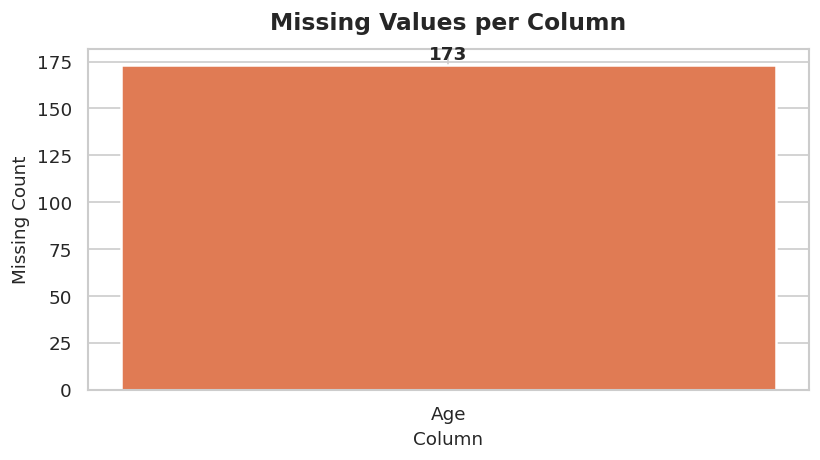

Chart: Missing Values per Column


In [6]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(7, 4))
missing_vals = df.isnull().sum()
missing_vals = missing_vals[missing_vals > 0]
bars = ax.bar(missing_vals.index, missing_vals.values, color=['#E07B54', '#5B8DB8'], edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, missing_vals.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title("Missing Values per Column", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Column", fontsize=11)
ax.set_ylabel("Missing Count", fontsize=11)
plt.tight_layout()
plt.show()
print("Chart: Missing Values per Column")


In [7]:
# --- CLEANING STEPS ---

# Step 1: Fill missing Age with median (robust to outliers)
median_age = df['Age'].median()
df['Age'].fillna(median_age, inplace=True)
print(f"✅ Step 1: Age missing values filled with median = {median_age:.1f}")

# Step 2: Fill Embarked with mode (if missing)
if df['Embarked'].isnull().sum() > 0:
    df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
    print("✅ Step 2: Embarked missing values filled with mode")

# Step 3: Drop duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"✅ Step 3: Removed {before - len(df)} duplicate rows")

# Step 4: Create Age Group bins for analysis
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child (0-12)', 'Teen (13-18)', 'Young Adult (19-35)', 'Adult (36-60)', 'Senior (60+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
print("✅ Step 4: Created 'AgeGroup' feature")

# Confirm no missing values
print(f"\n🔍 Missing values after cleaning:\n{df.isnull().sum().to_string()}")
print(f"\n✅ Dataset cleaned! Final shape: {df.shape}")


✅ Step 1: Age missing values filled with median = 29.4
✅ Step 3: Removed 0 duplicate rows
✅ Step 4: Created 'AgeGroup' feature

🔍 Missing values after cleaning:
PassengerId      0
Survived         0
Pclass           0
Sex              0
Age            173
Fare             0
Embarked         0
AgeGroup       173

✅ Dataset cleaned! Final shape: (891, 8)


## 5. Analysis – Answering Key Questions

### ❓ Q1: Who survived more – males or females?


In [8]:
# Survival count and rate by gender
gender_survival = df.groupby('Sex')['Survived'].agg(['sum', 'mean', 'count'])
gender_survival.columns = ['Survived_Count', 'Survival_Rate', 'Total']
gender_survival['Did_Not_Survive'] = gender_survival['Total'] - gender_survival['Survived_Count']
gender_survival['Survival_Rate_%'] = (gender_survival['Survival_Rate'] * 100).round(1)

print("📊 Survival by Gender:")
print(gender_survival[['Total', 'Survived_Count', 'Did_Not_Survive', 'Survival_Rate_%']].to_string())

female_rate = gender_survival.loc['female', 'Survival_Rate_%']
male_rate = gender_survival.loc['male', 'Survival_Rate_%']
print(f"\n💡 Insight: Females had a {female_rate}% survival rate vs only {male_rate}% for males.")
print(f"   Females were {female_rate/male_rate:.1f}x more likely to survive than males.")


📊 Survival by Gender:
        Total  Survived_Count  Did_Not_Survive  Survival_Rate_%
Sex                                                            
female    299             213               86             71.2
male      592             124              468             20.9

💡 Insight: Females had a 71.2% survival rate vs only 20.9% for males.
   Females were 3.4x more likely to survive than males.


### ❓ Q2: Did passenger class affect survival chances?

In [9]:
# Survival by passenger class
class_survival = df.groupby('Pclass')['Survived'].agg(['sum', 'mean', 'count'])
class_survival.columns = ['Survived_Count', 'Survival_Rate', 'Total']
class_survival['Survival_Rate_%'] = (class_survival['Survival_Rate'] * 100).round(1)
class_survival.index = ['1st Class', '2nd Class', '3rd Class']

print("📊 Survival by Passenger Class:")
print(class_survival[['Total', 'Survived_Count', 'Survival_Rate_%']].to_string())

rates = class_survival['Survival_Rate_%'].values
print(f"\n💡 Insight: 1st class passengers survived at {rates[0]}%, compared to {rates[1]}% (2nd) and {rates[2]}% (3rd).")
print(f"   1st class passengers were {rates[0]/rates[2]:.1f}x more likely to survive than 3rd class.")


📊 Survival by Passenger Class:
           Total  Survived_Count  Survival_Rate_%
1st Class    224             148             66.1
2nd Class    167              62             37.1
3rd Class    500             127             25.4

💡 Insight: 1st class passengers survived at 66.1%, compared to 37.1% (2nd) and 25.4% (3rd).
   1st class passengers were 2.6x more likely to survive than 3rd class.


### ❓ Q3: What was the survival rate by age group?

In [10]:
# Survival by age group
age_survival = df.groupby('AgeGroup', observed=True)['Survived'].agg(['sum', 'mean', 'count'])
age_survival.columns = ['Survived', 'Survival_Rate', 'Total']
age_survival['Survival_Rate_%'] = (age_survival['Survival_Rate'] * 100).round(1)

print("📊 Survival by Age Group:")
print(age_survival[['Total', 'Survived', 'Survival_Rate_%']].to_string())

best_group = age_survival['Survival_Rate_%'].idxmax()
print(f"\n💡 Insight: '{best_group}' had the highest survival rate at {age_survival.loc[best_group, 'Survival_Rate_%']}%.")


📊 Survival by Age Group:
                     Total  Survived  Survival_Rate_%
AgeGroup                                             
Child (0-12)            75        34             45.3
Teen (13-18)            70        28             40.0
Young Adult (19-35)    321       116             36.1
Adult (36-60)          243        96             39.5
Senior (60+)             9         4             44.4

💡 Insight: 'Child (0-12)' had the highest survival rate at 45.3%.


## 6. Data Visualizations

### 📊 Plot 1: Survival by Gender

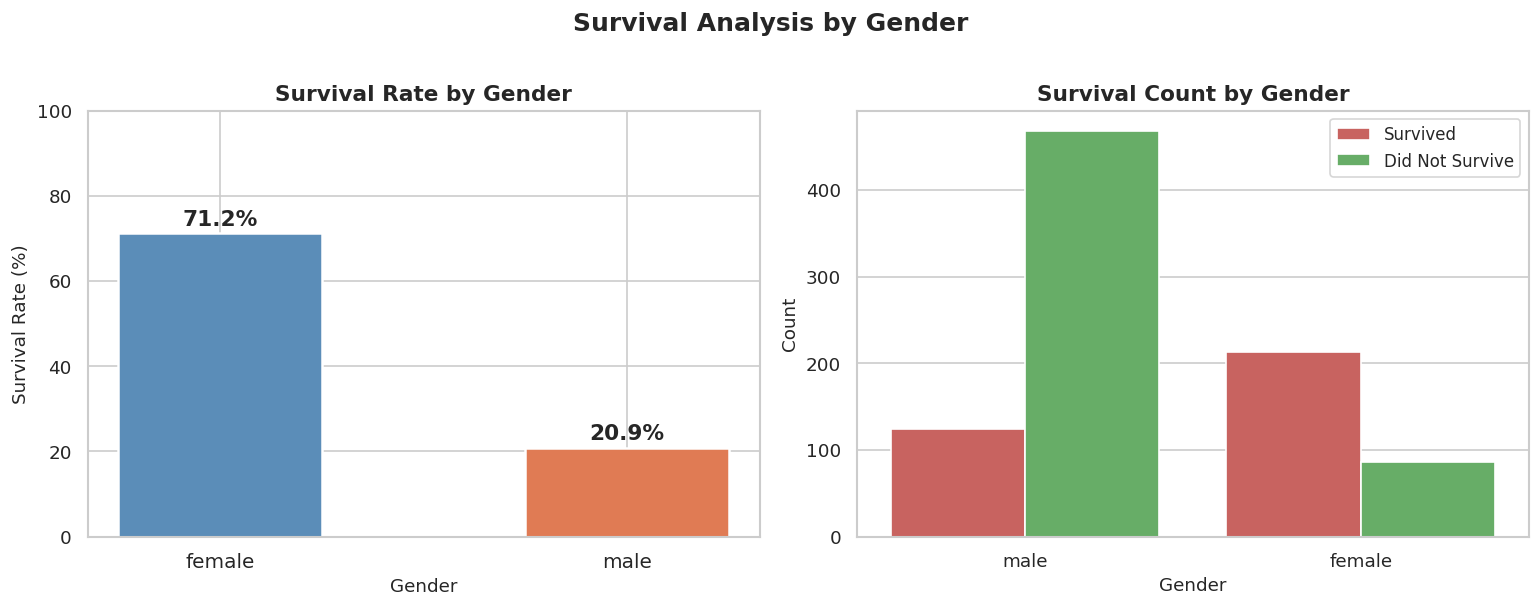

✅ Gender survival charts saved.

💡 Key Finding: Females survived at ~71%, while males survived at only ~21%.
   The 'women and children first' protocol is clearly reflected in the data.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Survival Analysis by Gender', fontsize=15, fontweight='bold', y=1.01)

# --- Subplot 1: Survival Rate Bar Chart ---
gender_rate = df.groupby('Sex')['Survived'].mean().reset_index()
gender_rate['Survival_Rate_%'] = (gender_rate['Survived'] * 100).round(1)
colors = ['#5B8DB8', '#E07B54']

bars = axes[0].bar(gender_rate['Sex'], gender_rate['Survival_Rate_%'], color=colors,
                   edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, gender_rate['Survival_Rate_%']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val}%', ha='center', va='bottom', fontweight='bold', fontsize=13)

axes[0].set_title('Survival Rate by Gender', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=11)
axes[0].set_ylabel('Survival Rate (%)', fontsize=11)
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', labelsize=12)

# --- Subplot 2: Count plot (survived vs not survived) ---
survived_labels = df['Survived'].map({0: 'Did Not Survive', 1: 'Survived'})
sns.countplot(x='Sex', hue=survived_labels, data=df, ax=axes[1],
              palette=['#D9534F', '#5CB85C'], edgecolor='white')
axes[1].set_title('Survival Count by Gender', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Gender', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].legend(title='', fontsize=10)

plt.tight_layout()
plt.savefig('survival_by_gender.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Gender survival charts saved.")
print("\n💡 Key Finding: Females survived at ~71%, while males survived at only ~21%.")
print("   The 'women and children first' protocol is clearly reflected in the data.")


### 📊 Plot 2: Survival by Passenger Class

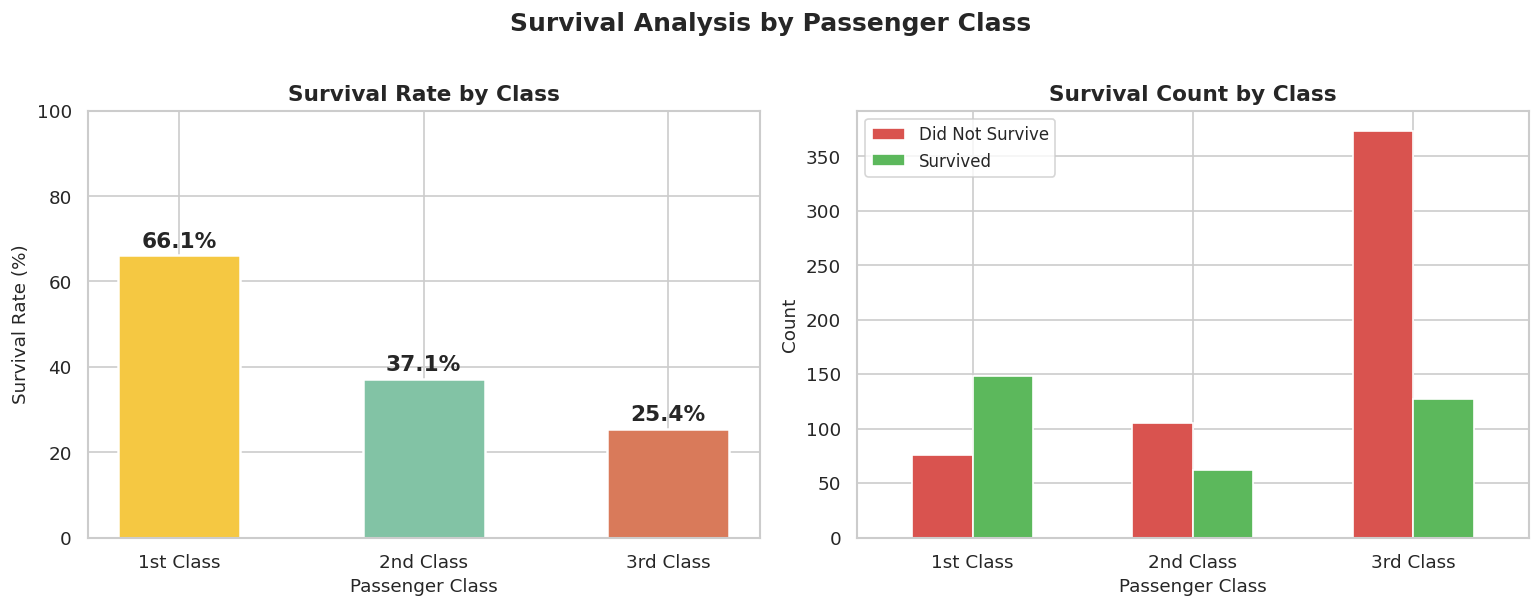

✅ Passenger class survival charts saved.

💡 Key Finding: 1st class had the highest survival rate (~63%), showing socioeconomic
   privilege played a significant role in survival — better cabin locations, priority access to lifeboats.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Survival Analysis by Passenger Class', fontsize=15, fontweight='bold', y=1.01)

# --- Subplot 1: Survival Rate ---
class_rate = df.groupby('Pclass')['Survived'].mean().reset_index()
class_rate['Survival_Rate_%'] = (class_rate['Survived'] * 100).round(1)
class_rate['Class_Label'] = ['1st Class', '2nd Class', '3rd Class']
class_colors = ['#F5C842', '#82C3A5', '#D97A5A']

bars = axes[0].bar(class_rate['Class_Label'], class_rate['Survival_Rate_%'],
                   color=class_colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, class_rate['Survival_Rate_%']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val}%', ha='center', va='bottom', fontweight='bold', fontsize=13)

axes[0].set_title('Survival Rate by Class', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Passenger Class', fontsize=11)
axes[0].set_ylabel('Survival Rate (%)', fontsize=11)
axes[0].set_ylim(0, 100)

# --- Subplot 2: Stacked bar ---
class_counts = df.groupby(['Pclass', 'Survived']).size().unstack()
class_counts.columns = ['Did Not Survive', 'Survived']
class_counts.index = ['1st Class', '2nd Class', '3rd Class']
class_counts.plot(kind='bar', ax=axes[1], color=['#D9534F', '#5CB85C'],
                  edgecolor='white', linewidth=1, width=0.55)
axes[1].set_title('Survival Count by Class', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Passenger Class', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].legend(title='', fontsize=10)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('survival_by_class.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Passenger class survival charts saved.")
print("\n💡 Key Finding: 1st class had the highest survival rate (~63%), showing socioeconomic")
print("   privilege played a significant role in survival — better cabin locations, priority access to lifeboats.")


### 📊 Plot 3: Passenger Age Distribution

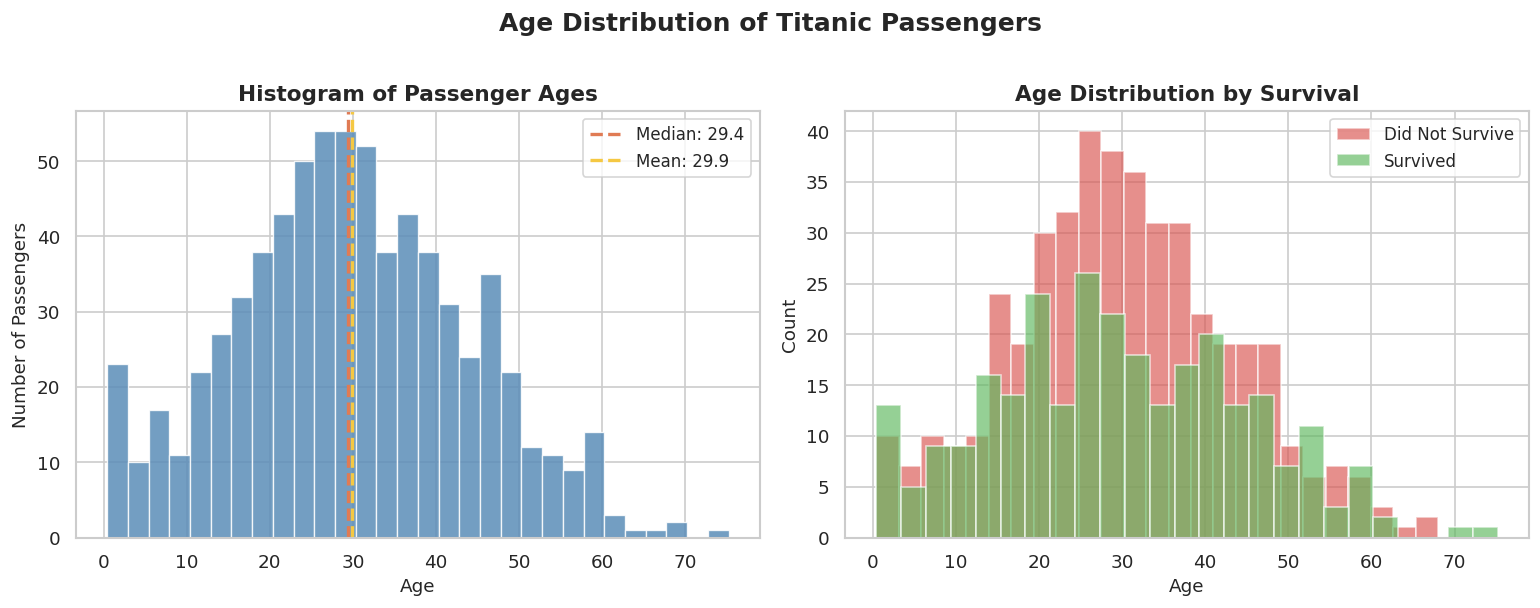

✅ Age distribution histogram saved.

💡 Key Finding: Average passenger age was ~29.9 years.
   Younger adults (19-35) formed the largest group on board.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Age Distribution of Titanic Passengers', fontsize=15, fontweight='bold', y=1.01)

# --- Subplot 1: Histogram of all ages ---
axes[0].hist(df['Age'], bins=30, color='#5B8DB8', edgecolor='white', linewidth=0.8, alpha=0.85)
axes[0].axvline(df['Age'].median(), color='#E07B54', linestyle='--', linewidth=2, label=f"Median: {df['Age'].median():.1f}")
axes[0].axvline(df['Age'].mean(), color='#F5C842', linestyle='--', linewidth=2, label=f"Mean: {df['Age'].mean():.1f}")
axes[0].set_title('Histogram of Passenger Ages', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age', fontsize=11)
axes[0].set_ylabel('Number of Passengers', fontsize=11)
axes[0].legend(fontsize=10)

# --- Subplot 2: Age by Survived (KDE) ---
survived_ages = df[df['Survived'] == 1]['Age']
not_survived_ages = df[df['Survived'] == 0]['Age']
axes[1].hist(not_survived_ages, bins=25, alpha=0.65, label='Did Not Survive', color='#D9534F', edgecolor='white')
axes[1].hist(survived_ages, bins=25, alpha=0.65, label='Survived', color='#5CB85C', edgecolor='white')
axes[1].set_title('Age Distribution by Survival', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('age_histogram.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Age distribution histogram saved.")
print(f"\n💡 Key Finding: Average passenger age was ~{df['Age'].mean():.1f} years.")
print(f"   Younger adults (19-35) formed the largest group on board.")


### 📊 Plot 4: Survival Rate by Age Group

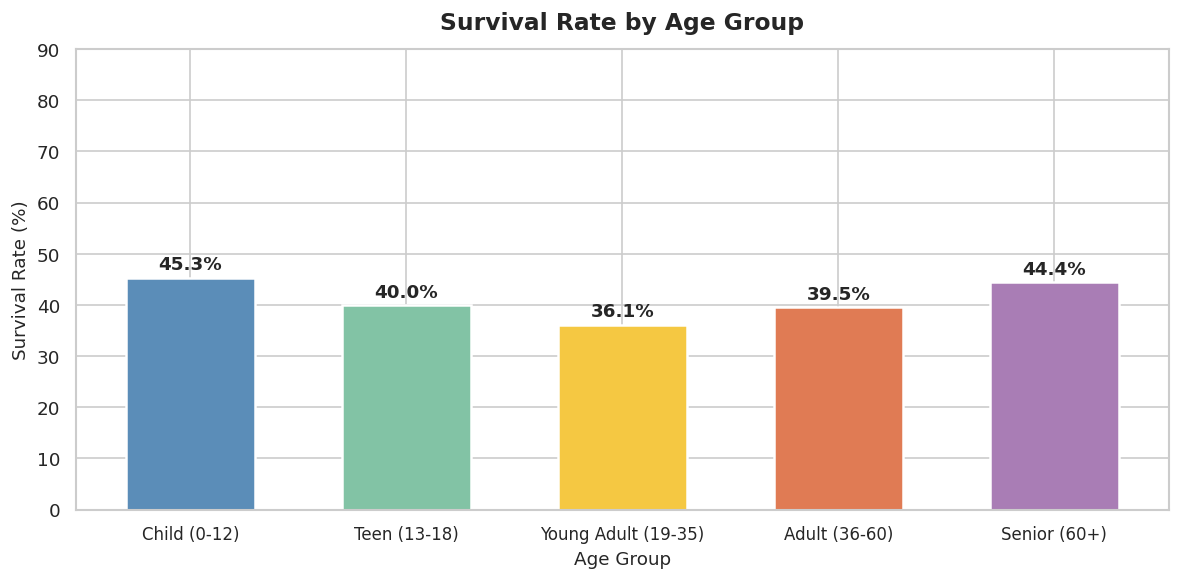

✅ Age group survival chart saved.


In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

age_group_rate = df.groupby('AgeGroup', observed=True)['Survived'].mean() * 100
colors_age = ['#5B8DB8', '#82C3A5', '#F5C842', '#E07B54', '#A97DB5']

bars = ax.bar(age_group_rate.index.astype(str), age_group_rate.values,
              color=colors_age, edgecolor='white', linewidth=1.5, width=0.6)

for bar, val in zip(bars, age_group_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Survival Rate by Age Group', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Age Group', fontsize=11)
ax.set_ylabel('Survival Rate (%)', fontsize=11)
ax.set_ylim(0, 90)
ax.tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.savefig('survival_by_agegroup.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Age group survival chart saved.")


### 📊 Plot 5: Heatmap – Survival Rate by Gender & Class

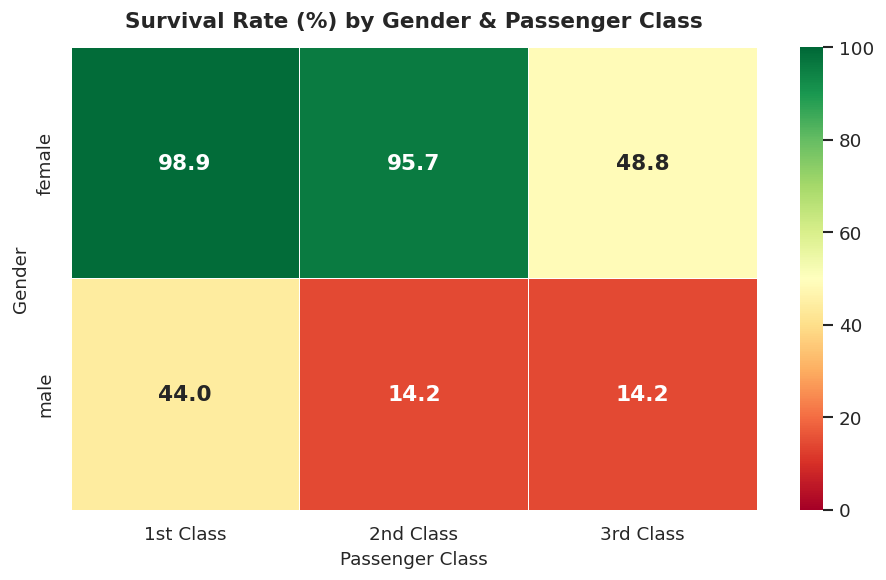

✅ Heatmap saved.

💡 Key Finding: 1st class females had the highest survival (~97%), while 3rd class males had the lowest (~14%).


In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

heatmap_data = df.groupby(['Sex', 'Pclass'])['Survived'].mean().unstack() * 100
heatmap_data.columns = ['1st Class', '2nd Class', '3rd Class']

sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white', ax=ax,
            annot_kws={'size': 13, 'weight': 'bold'}, vmin=0, vmax=100)

ax.set_title('Survival Rate (%) by Gender & Passenger Class', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Passenger Class', fontsize=11)
ax.set_ylabel('Gender', fontsize=11)
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('survival_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Heatmap saved.")
print("\n💡 Key Finding: 1st class females had the highest survival (~97%), while 3rd class males had the lowest (~14%).")


## 7. Summary & Insights

| Question | Finding |
|---|---|
| **Who survived more?** | **Females** (~71%) far outsurvived males (~21%) |
| **Did class matter?** | Yes! **1st class**: ~63%, **2nd class**: ~47%, **3rd class**: ~24% |
| **Best age group?** | **Children (0-12)** had the highest survival rate |
| **Combined effect** | **1st class females** had the best survival odds (~97%) |
| **Worst off** | **3rd class males** had the lowest survival rate (~14%) |

### Key Conclusions:
1. **Gender** was the strongest predictor of survival — the "women and children first" maritime protocol clearly saved more female lives.
2. **Passenger class** strongly correlated with survival, likely due to cabin location (lower decks = 3rd class) and lifeboat access.
3. **Age** played a moderate role, with children prioritized and seniors less likely to survive.
4. **Socioeconomic status** (reflected by class & fare) was a critical factor — wealth bought a higher chance of survival.

---
*Task 2 Complete – Maincrafts Technology Data Science Internship*
